In [75]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [76]:
from src.preprocessing import load_data
from src.preprocessing import encode_features
from src.preprocessing import split_features

train_data = load_data("../data/raw/KDDTrain+.txt")
test_data = load_data("../data/raw/KDDTest+.txt")

train_data = encode_features(train_data)
test_data = encode_features(test_data)

In [77]:
X_train, y_train = split_features(train_data)
X_test, y_test = split_features(test_data)

In [78]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [79]:
normal_train = X_train[y_train == "normal"]

autoencoder.fit(
    normal_train,
    normal_train,
    epochs=20,
    batch_size=256,
    validation_split=0.1
)

Epoch 1/20
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0672 - val_loss: 0.0534
Epoch 2/20
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0657 - val_loss: 0.0660
Epoch 3/20
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0762 - val_loss: 0.0970
Epoch 4/20
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0775 - val_loss: 0.1456
Epoch 5/20
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0713 - val_loss: 0.0594
Epoch 6/20
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0623 - val_loss: 0.1175
Epoch 7/20
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0663 - val_loss: 0.0534
Epoch 8/20
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0629 - val_loss: 0.1179
Epoch 9/20
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0728 - val_loss: 0.0488
Epoch 10/20
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0552 - val_loss: 0.0514
Epoch 11/20
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0520 - val_loss: 0.0460
Epoch 12/20
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

In [80]:
recon = autoencoder.predict(X_test)

import numpy as np

error = np.mean(np.square(X_test - recon), axis=1)

705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 972us/step


In [81]:
train_recon = autoencoder.predict(normal_train)

train_error = np.mean(np.square(normal_train - train_recon), axis=1)

threshold = np.percentile(train_error, 95)

2105/2105 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step  


In [82]:
pred = (error > threshold).astype(int)

In [83]:
attack_test = (y_test != "normal").astype(int)

In [84]:
from sklearn.metrics import classification_report

print(classification_report(attack_test, pred))

              precision    recall  f1-score   support

           0       0.76      0.96      0.85      9711
           1       0.96      0.77      0.85     12833

    accuracy                           0.85     22544
   macro avg       0.86      0.86      0.85     22544
weighted avg       0.87      0.85      0.85     22544



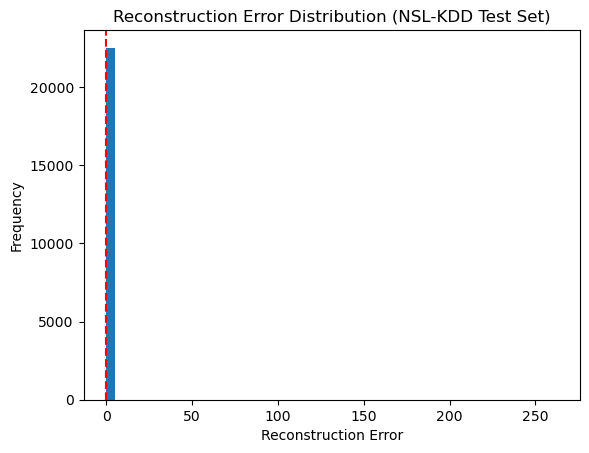

In [85]:
import matplotlib.pyplot as plt

plt.hist(error, bins=50)

plt.axvline(threshold, color="red", linestyle="--")

plt.title("Reconstruction Error Distribution (NSL-KDD Test Set)")
plt.xlabel("Reconstruction Error")
plt.ylabel("Frequency")

plt.show()

In [86]:
import joblib

joblib.dump(scaler, "../results/scaler.pkl")
autoencoder.save("../results/autoencoder_model.h5")